In [ ]:
# ==============================================================================
# ADIM 1: ALTYAPI KURULUMU VE VERİ SETİ HAZIRLIĞI (YENİDEN BAŞLANGIÇ)
# Proje: Su Altı Canlıları Tespiti Akademik Bildirisi
# ==============================================================================
import os
import yaml
from google.colab import drive

print("🔌 1. Google Drive Bağlantısı Kuruluyor...")
drive.mount('/content/drive')

print("\n⚙️ 2. Ultralytics Kütüphanesi Kuruluyor...")
!pip install ultralytics -q

print("\n📦 3. Veri Seti Geçici Hafızaya Çıkarılıyor (Hızlı Eğitim İçin)...")
zip_yolu = "/content/drive/MyDrive/veri_seti.zip"
hedef_klasor = "/content/aquarium_dataset"

# Temiz bir çıkarma işlemi için eğer eski klasör varsa kontrol edip çıkartıyoruz
if not os.path.exists(hedef_klasor):
    !unzip -q "{zip_yolu}" -d "{hedef_klasor}"
    print("✅ Veri seti Colab diskine başarıyla çıkarıldı!")
else:
    !unzip -q -o "{zip_yolu}" -d "{hedef_klasor}"
    print("✅ Veri seti üzerine yazılarak tazeleyip hazırlandı!")

print("\n📝 4. Modeller İçin 'dataset.yaml' Yapılandırma Dosyası Oluşturuluyor...")
data_config = {
    'train': f'{hedef_klasor}/aquarium_pretrain/train/images',
    'val': f'{hedef_klasor}/aquarium_pretrain/valid/images',
    'test': f'{hedef_klasor}/aquarium_pretrain/test/images',
    'nc': 7,
    'names': ['fish', 'jellyfish', 'penguin', 'puffin', 'shark', 'starfish', 'stingray']
}

# YAML dosyasını kök dizine yazıyoruz
with open('/content/dataset.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("\n🎉 ADIM 1 BAŞARIYLA TAMAMLANDI!")
print("Sistem sıfırlandı, veriler tazelendi. Şimdi Adım 2 (Baseline) için hazırsınız.")

🔌 1. Google Drive Bağlantısı Kuruluyor...
Mounted at /content/drive

⚙️ 2. Ultralytics Kütüphanesi Kuruluyor...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.0 MB/s eta 0:00:00

📦 3. Veri Seti Geçici Hafızaya Çıkarılıyor (Hızlı Eğitim İçin)...
✅ Veri seti Colab diskine başarıyla çıkarıldı!

📝 4. Modeller İçin 'dataset.yaml' Yapılandırma Dosyası Oluşturuluyor...

🎉 ADIM 1 BAŞARIYLA TAMAMLANDI!
Sistem sıfırlandı, veriler tazelendi. Şimdi Adım 2 (Baseline) için hazırsınız.


In [ ]:
# ==============================================================================
# ADIM 2: REFERANS ÇİZGİSİ (BASELINE MODEL)
# Model: YOLOv8-Nano (Standart Ayarlar)
# Amaç: Su altı ortamının zorluğunu hafif bir modelle kanıtlamak.
# ==============================================================================
from ultralytics import YOLO

print("📊 ADIM 2 BAŞLIYOR: YOLOv8-Nano Temel Eğitimi...\n")

# 1. En hafif modeli yüklüyoruz (Baseline)
model_nano = YOLO('yolov8n.pt')

# 2. Standart ayarlarla 30 epoch eğitim
# Not: Burada bilerek ağır optimizasyonlar kullanmıyoruz.
results_nano = model_nano.train(
    data='/content/dataset.yaml',
    epochs=30,
    patience=10,
    imgsz=640,
    batch=16,          # Nano model çok hafif olduğu için GPU 16 resmi rahatça taşır
    optimizer='auto',
    val=True,

    # Standart veri artırmaları (Diğer modellerle adil kıyaslama için hepsinde aynı olacak)
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=15.0, translate=0.1, scale=0.5, fliplr=0.5,
    mosaic=1.0, mixup=0.1,

    # Çıktıları doğrudan Drive'a kaydediyoruz (Öncekilerle karışmaması için ismine 'Yeni' ekledik)
    project='/content/drive/MyDrive/Su_Alti_Makale_Projesi',
    name='YOLOv8_Nano_Baseline_Yeni'
)

print("\n✅ EĞİTİM BİTTİ! ŞİMDİ TEMEL TEST (VAL) YAPILIYOR...\n")

# 3. Modelin nihai performansını alıyoruz (TTA yok!)
metrics_nano = model_nano.val()

print("\n📉 YOLOv8-NANO (REFERANS MODEL) BAŞARIM METRİKLERİ")
print("-" * 55)
print(f"Ortalama Hassasiyet (mAP@50):    %{metrics_nano.box.map50 * 100:.2f}")
print(f"Genel Hassasiyet (mAP@50-95):    %{metrics_nano.box.map * 100:.2f}")
print(f"Kesinlik (Precision):            %{metrics_nano.box.mp * 100:.2f}")
print(f"Duyarlılık (Recall):             %{metrics_nano.box.mr * 100:.2f}\n")

print("🎉 ADIM 2 TAMAMLANDI! Grafikleriniz Drive'a kaydedildi.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📊 ADIM 2 BAŞLIYOR: YOLOv8-Nano Temel Eğitimi...

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=F

In [ ]:
# ==============================================================================
# ADIM 3: SINIRLARI ZORLAMA (AĞIR SİKLET)
# Model: YOLO11-Large + TTA (Test Zamanı Artırımı)
# Amaç: CNN mimarisiyle veri setinden elde edilebilecek maksimum skoru bulmak.
# ==============================================================================
from ultralytics import YOLO

print("🚀 ADIM 3 BAŞLIYOR: YOLO11-Large Ağır Siklet Eğitimi...\n")

# 1. En yeni ve derin mimariyi yüklüyoruz
model_large = YOLO('yolo11l.pt')

# 2. Su altı zorluklarına karşı aynı veri artırmaları ile 30 Epoch Eğitim
results_large = model_large.train(
    data='/content/dataset.yaml',
    epochs=30,
    patience=10,
    imgsz=640,
    batch=8,           # Large model ağır olduğu için batch 8'de (GPU'yu korumak için)
    optimizer='auto',
    val=True,

    # Adım 2 ile BİREBİR aynı veri artırmaları (Adil kıyaslama için)
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=15.0, translate=0.1, scale=0.5, fliplr=0.5,
    mosaic=1.0, mixup=0.1,

    # Çıktıları doğrudan Drive'a kaydediyoruz (Karışmaması için yeni isimle)
    project='/content/drive/MyDrive/Su_Alti_Makale_Projesi',
    name='YOLO11_Large_TTA_Yeni'
)

print("\n✅ EĞİTİM BİTTİ! ŞİMDİ TTA İLE NİHAİ SINAV YAPILIYOR...\n")

# 3. Modelin sınırlarını zorlayan TTA devrede (augment=True)
metrics_large = model_large.val(augment=True)

print("\n🏆 YOLO11-LARGE + TTA BAŞARIM METRİKLERİ")
print("-" * 55)
print(f"Ortalama Hassasiyet (mAP@50):    %{metrics_large.box.map50 * 100:.2f}")
print(f"Genel Hassasiyet (mAP@50-95):    %{metrics_large.box.map * 100:.2f}")
print(f"Kesinlik (Precision):            %{metrics_large.box.mp * 100:.2f}")
print(f"Duyarlılık (Recall):             %{metrics_large.box.mr * 100:.2f}\n")

print("🎉 ADIM 3 TAMAMLANDI! Şampiyon YOLO modelinizin verileri Drive'a kaydedildi.")

🚀 ADIM 3 BAŞLIYOR: YOLO11-Large Ağır Siklet Eğitimi...

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11_Large_TTA_Yeni, nbs=64, nms=False, opset=None, 

In [ ]:
# ==============================================================================
# ADIM 4: MİMARİ KAPIŞMA (TRANSFORMER)
# Model: RT-DETR-Large (Real-Time DEtection TRansformer)
# Amaç: CNN mimarisine karşı Transformer mimarisini test edip "Veri Tavanını" kanıtlamak.
# ==============================================================================
from ultralytics import RTDETR

print("🥊 ADIM 4 BAŞLIYOR: Transformer Tabanlı RT-DETR Eğitimi...\n")

# 1. Tamamen farklı bir mimari: Vision Transformer tabanlı model yükleniyor
model_detr = RTDETR('rtdetr-l.pt')

# 2. YOLO modelleriyle tamamen "adil" ve "eşit" şartlarda 30 Epoch Eğitim
results_detr = model_detr.train(
    data='/content/dataset.yaml',
    epochs=30,
    patience=10,
    imgsz=640,
    batch=4,           # Transformer belleği çok yorduğu için batch'i 4'te tutuyoruz (T4 GPU Güvenliği)
    optimizer='auto',
    val=True,

    # Diğer adımlarla BİREBİR aynı su altı veri artırmaları
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=15.0, translate=0.1, scale=0.5, fliplr=0.5,
    mosaic=1.0, mixup=0.1,

    # Çıktıları doğrudan Drive'a kaydediyoruz
    project='/content/drive/MyDrive/Su_Alti_Makale_Projesi',
    name='RT_DETR_Large_Yeni'
)

print("\n✅ EĞİTİM BİTTİ! ŞİMDİ NİHAİ TEST (VAL) YAPILIYOR...\n")

# 3. Modelin test performansını alıyoruz
metrics_detr = model_detr.val()

print("\n🏆 RT-DETR (TRANSFORMER) BAŞARIM METRİKLERİ")
print("-" * 55)
print(f"Ortalama Hassasiyet (mAP@50):    %{metrics_detr.box.map50 * 100:.2f}")
print(f"Genel Hassasiyet (mAP@50-95):    %{metrics_detr.box.map * 100:.2f}")
print(f"Kesinlik (Precision):            %{metrics_detr.box.mp * 100:.2f}")
print(f"Duyarlılık (Recall):             %{metrics_detr.box.mr * 100:.2f}\n")

print("🎉 ADIM 4 TAMAMLANDI! Mutfaktaki tüm malzemeler hazır.")

🥊 ADIM 4 BAŞLIYOR: Transformer Tabanlı RT-DETR Eğitimi...

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=RT_DETR_Large_Yeni, nbs=64, nms=False, opset=None,

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      11.5G      1.308      1.827     0.4428          4       1280: 100% ━━━━━━━━━━━━ 112/112 1.1s/it 2:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.1it/s 7.7s
                   all        127        909     0.0329      0.616     0.0852     0.0378

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      11.7G     0.9807     0.7486     0.3108          4       1280: 100% ━━━━━━━━━━━━ 112/112 1.1s/it 1:58
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.5it/s 2.5s
                   all        127        909      0.497      0.351      0.278      0.134

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      22/30      4.29G     0.4433     0.4974     0.1915          4        640: 100% ━━━━━━━━━━━━ 112/112 2.1it/s 53.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.3it/s 2.5s
                   all        127        909      0.821      0.737      0.797      0.409

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      23/30      4.29G     0.5319     0.4594     0.1007          4        640: 0% ──────────── 0/112  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      23/30      4.29G     0.4573     0.4864     0.1893          4        640: 100% ━━━━━━━━━━━━ 112/112 2.1it/s 53.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 5.2it/s 3.1s
                   all        127        909      0.755      0.751      0.779      0.351

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      24/30      4.29G     0.4733     0.4473     0.4378          4        640: 0% ──────────── 0/112  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      24/30      4.29G     0.4372     0.4835     0.1821          4        640: 100% ━━━━━━━━━━━━ 112/112 2.1it/s 52.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 4.8it/s 3.3s
                   all        127        909      0.748      0.773      0.782      0.399
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 14, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

24 epochs completed in 0.895 hours.
Optimizer stripped from /content/drive/MyDrive/Su_Alti_Makale_Projesi/RT_DETR_Large_Yeni/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/Su_Alti_Makale_Projesi/RT_DETR_Large_Yeni/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/Su_Alti_Makale_Projesi/RT_DETR_Large_Yeni/weights/best.pt...
Ultralytics 8.4.56 🚀 Python-

📊 Makale uyumlu yeni grafik çiziliyor...



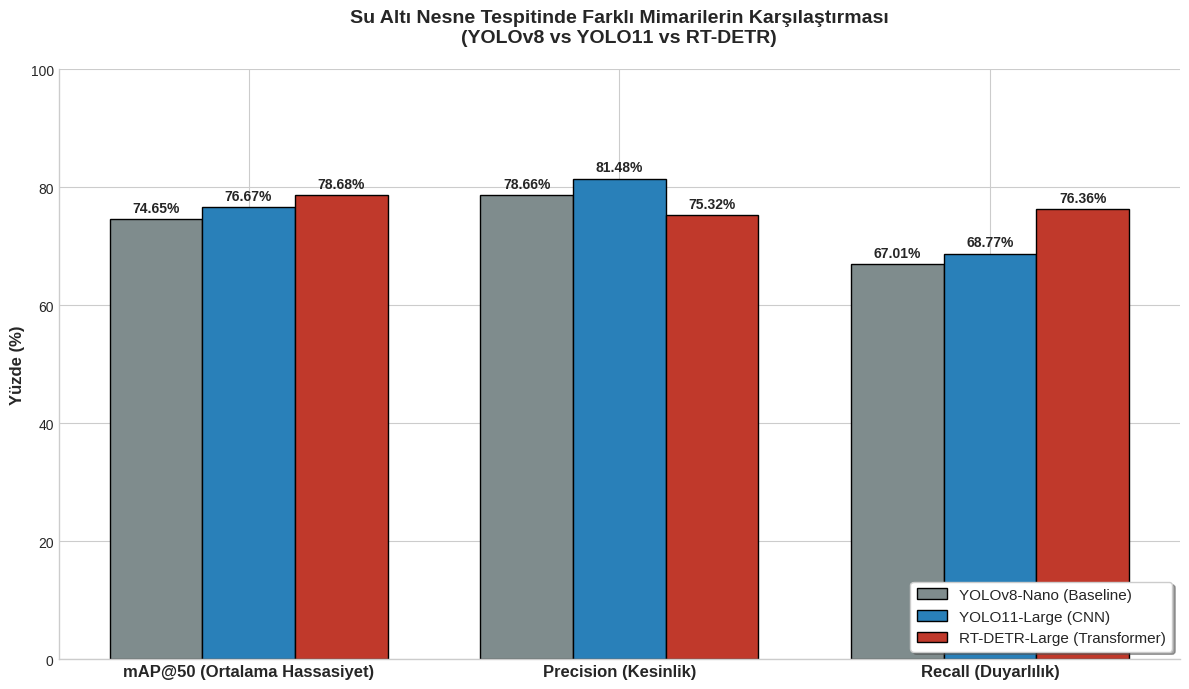

🎉 GRAFİK HAZIR VE TABLO İLE %100 UYUMLU!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("📊 Makale uyumlu yeni grafik çiziliyor...\n")

# Tablo 1'deki KESİN ve NİHAİ değerler (mAP, Precision, Recall)
metrikler = {
    "YOLOv8-Nano (Baseline)": [74.65, 78.66, 67.01],
    "YOLO11-Large (CNN)": [76.67, 81.48, 68.77],
    "RT-DETR-Large (Transformer)": [78.68, 75.32, 76.36]
}

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

kategoriler = ['mAP@50 (Ortalama Hassasiyet)', 'Precision (Kesinlik)', 'Recall (Duyarlılık)']
x = np.arange(len(kategoriler))
genislik = 0.25

model_isimleri = list(metrikler.keys())
renkler = ['#7f8c8d', '#2980b9', '#c0392b']

for i, (model_adi, degerler) in enumerate(metrikler.items()):
    kayma = (i - 1) * genislik
    cubuklar = ax.bar(x + kayma, degerler, genislik, label=model_adi, color=renkler[i], edgecolor='black')
    ax.bar_label(cubuklar, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

ax.set_ylabel('Yüzde (%)', fontsize=12, fontweight='bold')
ax.set_title('Su Altı Nesne Tespitinde Farklı Mimarilerin Karşılaştırması\n(YOLOv8 vs YOLO11 vs RT-DETR)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(kategoriler, fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

kayit_yolu = '/content/Nihai_Karsilastirma_Grafigi_Guncel.png'
plt.tight_layout()
plt.savefig(kayit_yolu, dpi=300, bbox_inches='tight')

plt.show()
print(f"🎉 GRAFİK HAZIR VE TABLO İLE %100 UYUMLU!")

📊 GRAFİKLER HAFIZADAN ÇEKİLİYOR VE EKRANA ÇİZİLİYOR...


📉 KARMAŞIKLIK MATRİSİ (Confusion Matrix)


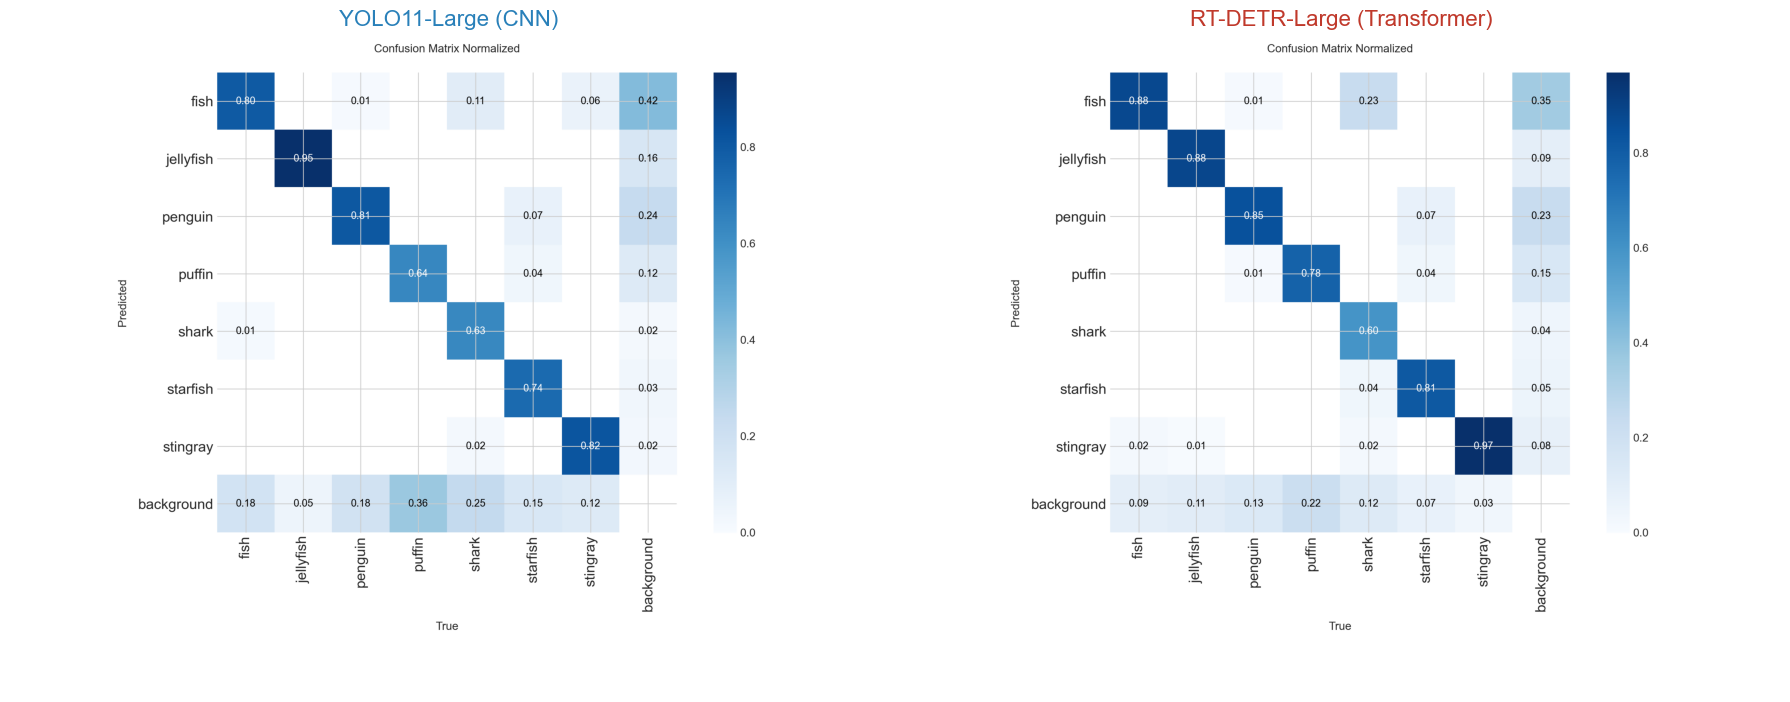




🎯 KESİNLİK-DUYARLILIK EĞRİSİ (PR Curve)


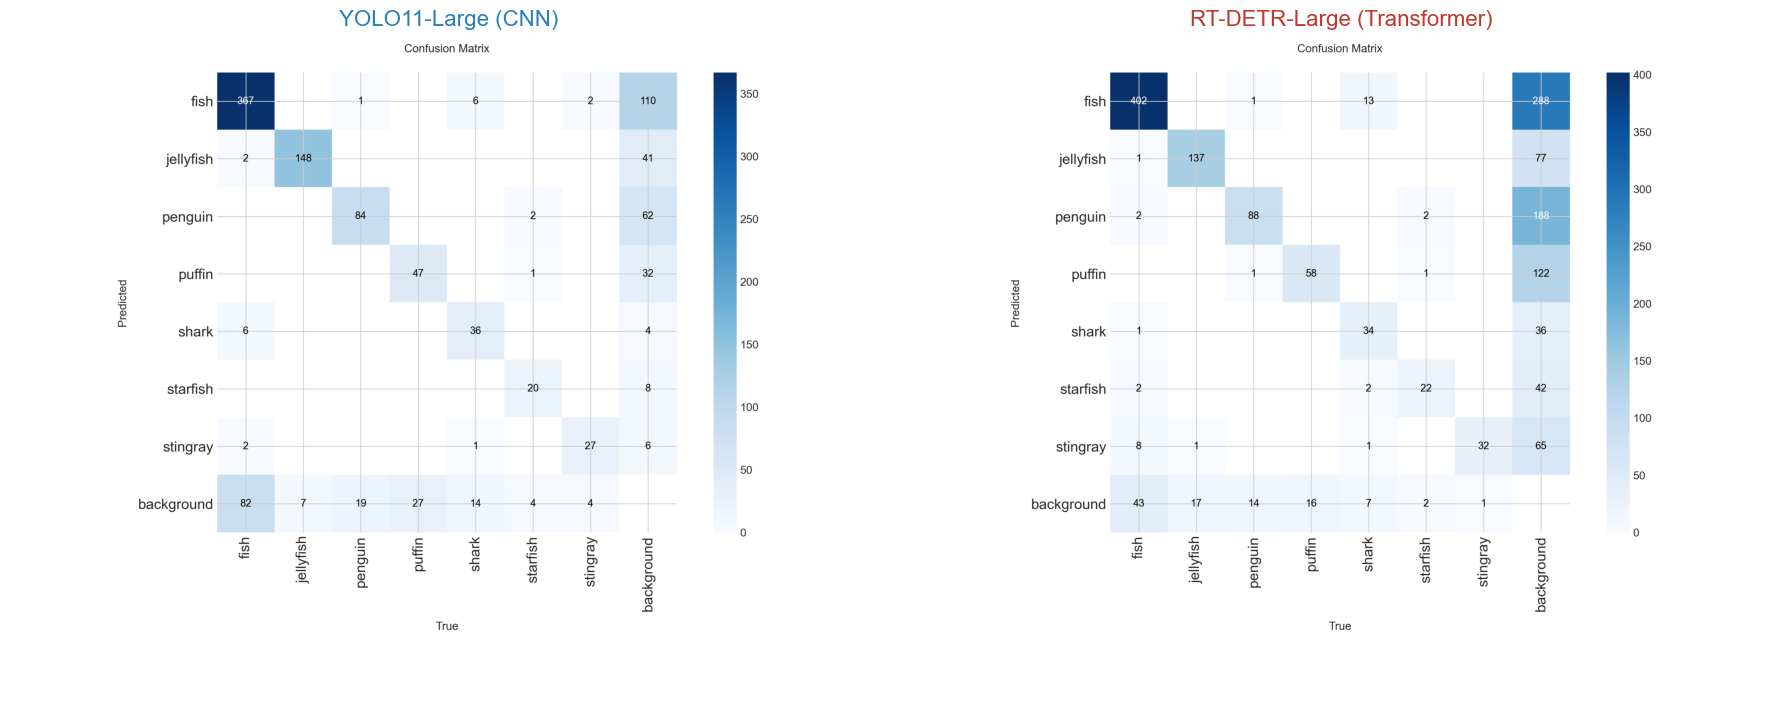

In [ ]:
# ==============================================================================
# GÜVENLİ EKRAN: YOLO11 vs RT-DETR GRAFİKLERİ (MATPLOTLIB)
# Açıklama: Colab HTML engelini aşarak resimleri doğrudan hafızadan ekrana basar.
# ==============================================================================
import os
import matplotlib.pyplot as plt
from PIL import Image

print("📊 GRAFİKLER HAFIZADAN ÇEKİLİYOR VE EKRANA ÇİZİLİYOR...\n")

grafikler = [
    ('📉 KARMAŞIKLIK MATRİSİ (Confusion Matrix)', 'confusion_matrix_normalized.png'),
    ('🎯 KESİNLİK-DUYARLILIK EĞRİSİ (PR Curve)', 'PR_curve.png')
]

for baslik, dosya_adi in grafikler:
    print("\n" + "="*80)
    print(baslik)
    print("="*80)

    # Yeni üretilen dosyaların yolları
    yolo_yol = f'/content/Makale_Grafikleri/YOLO11/{dosya_adi}'
    detr_yol = f'/content/Makale_Grafikleri/RTDETR/{dosya_adi}'

    # Alternatif isim kontrolü (normalized yoksa normalini al)
    if not os.path.exists(yolo_yol): yolo_yol = f'/content/Makale_Grafikleri/YOLO11/confusion_matrix.png'
    if not os.path.exists(detr_yol): detr_yol = f'/content/Makale_Grafikleri/RTDETR/confusion_matrix.png'

    # Yan yana iki çerçeve (subplot) oluşturuyoruz
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # YOLO Grafiği
    if os.path.exists(yolo_yol):
        img_yolo = Image.open(yolo_yol)
        axes[0].imshow(img_yolo)
        axes[0].set_title('YOLO11-Large (CNN)', fontsize=16, fontweight='bold', color='#2980b9')
        axes[0].axis('off') # Eksen çizgilerini kapat
    else:
        axes[0].text(0.5, 0.5, 'YOLO11 Çizimi Bulunamadı\nLütfen bir önceki acil kurtarma kodunu çalıştırdığınızdan emin olun.',
                     ha='center', va='center', fontsize=14, color='red')
        axes[0].axis('off')

    # RT-DETR Grafiği
    if os.path.exists(detr_yol):
        img_detr = Image.open(detr_yol)
        axes[1].imshow(img_detr)
        axes[1].set_title('RT-DETR-Large (Transformer)', fontsize=16, fontweight='bold', color='#c0392b')
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, 'RT-DETR Çizimi Bulunamadı\nLütfen bir önceki acil kurtarma kodunu çalıştırdığınızdan emin olun.',
                     ha='center', va='center', fontsize=14, color='red')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print("\n")